# Análise exploratória dos dados de câncer no Brasil

Dados provenientes do INCA (Instituto Nacional de Câncer) foram carregados para análise. Fonte dos dados: [INCA - Registro Hospitalar de Câncer](https://irhc.inca.gov.br/RHCNet/visualizaTabNetExterno.action) e [Kaggle](https://www.kaggle.com/datasets/rafatrindade/onco-360?select=raw_inca_registro_hospitalar.parquet).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

In [2]:
parquet_file_path = '../data/raw_inca_registro_hospitalar.parquet' 
data = pd.read_parquet(parquet_file_path, engine='pyarrow')

In [7]:
data.head(15)

,TPCASO,SEXO,IDADE,RACACOR,INSTRUC,HISTFAMC,ALCOOLIS,TABAGISM,ESTADRES,ANOPRIDI,...,PRITRATH,ESTDFIMT,UFUH,OCUPACAO,DTDIAGNO,DATAPRICON,DATAINITRT,DATAOBITO,BASDIAGSP,ESTADIAG
0,2,2,71.0,1,9,2,1,1,RJ,NaT,...,1,8,RJ,888,2002-03-10,2000-06-02,NaT,NaT,3,None
1,2,1,0.0,9,9,9,9,9,99,NaT,...,1,8,RJ,9999,2002-01-02,2000-12-11,NaT,NaT,3,None
2,1,2,49.0,1,9,2,1,1,RJ,NaT,...,2,9,RJ,799,2002-07-21,2000-05-31,2002-06-21,NaT,3,None
3,1,1,66.0,1,9,1,9,3,RJ,NaT,...,2,8,RJ,985,2002-05-27,2000-06-06,2002-04-15,NaT,3,None
4,1,2,60.0,1,9,1,1,3,RJ,NaT,...,2,9,RJ,9999,2002-08-21,2000-10-15,2002-07-09,NaT,3,None
5,2,1,46.0,9,9,9,3,1,RJ,NaT,...,1,8,RJ,999,2002-05-08,2000-12-12,NaT,2002-05-07,2,None
6,2,1,80.0,1,9,2,1,3,RJ,NaT,...,1,8,RJ,621,2002-03-11,2000-12-05,NaT,2002-05-31,3,None
7,1,2,47.0,2,9,1,1,1,RJ,NaT,...,2,8,RJ,888,2002-10-16,2000-12-15,2002-09-19,NaT,3,None
8,1,2,58.0,4,9,1,9,9,RJ,NaT,...,22,9,RJ,540,2003-10-14,2000-09-27,2004-02-15,NaT,3,None
9,2,1,55.0,1,9,2,9,3,RJ,NaT,...,1,8,RJ,951,2003-05-20,2000-12-12,NaT,NaT,3,None


In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5399686 entries, 0 to 5399685
Data columns (total 48 columns):
 #   Column         Dtype  
---  ------         -----  
 0   TPCASO         object 
 1   SEXO           object 
 2   IDADE          object 
 3   LOCALNAS       object 
 4   RACACOR        object 
 5   INSTRUC        object 
 6   CLIATEN        object 
 7   CLITRAT        object 
 8   HISTFAMC       object 
 9   ALCOOLIS       object 
 10  TABAGISM       object 
 11  ESTADRES       object 
 12  PROCEDEN       object 
 13  ANOPRIDI       object 
 14  ORIENC         object 
 15  EXDIAG         object 
 16  ESTCONJ        object 
 17  ANTRI          object 
 18  DTPRICON       object 
 19  DIAGANT        object 
 20  BASMAIMP       object 
 21  LOCTUDET       object 
 22  LOCTUPRI       object 
 23  TIPOHIST       object 
 24  LATERALI       object 
 25  LOCTUPRO       object 
 26  MAISUMTU       object 
 27  TNM            object 
 28  ESTADIAM       object 
 29  OUTROESTA     

In [3]:
# Deleta colunas irrelevantes ou com muita informação faltando
data = data.drop(columns=['VALOR_TOT', 'DTTRIAGE', 'MUUH', 'CNES', 'DTINITRT', 'LOCTUPRO', 'LATERALI', 'DTPRICON', 'ANTRI', 'ESTCONJ', 'PROCEDEN', 'CLITRAT', 'CLIATEN', 'LOCALNAS'])

In [ ]:
data = data.replace('nan', np.nan)

/tmp/ipykernel_5867/3688614251.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_values.index, y=missing_values.values, palette='viridis')


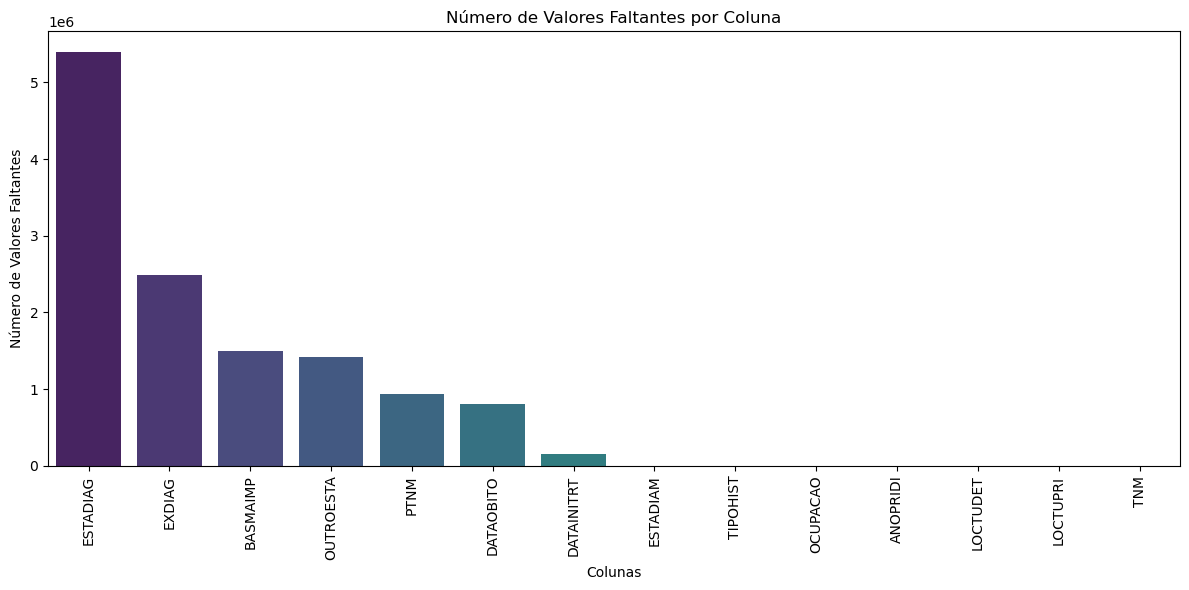

In [ ]:
missing_values = data.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_values.index, y=missing_values.values, palette='viridis')
plt.xticks(rotation=90)
plt.title('Número de Valores Faltantes por Coluna')
plt.ylabel('Número de Valores Faltantes')
plt.xlabel('Colunas')
plt.tight_layout()
plt.show()

## Coerência dos dados

In [4]:
# Convertendo colunas de datas para o formato datetime
date_cols = ['ANOPRIDI', 'DTDIAGNO', 'DATAINITRT', 'DATAOBITO', 'DATAPRICON']

for col in date_cols:
    if col in data.columns:
        data[col] = pd.to_datetime(
            data[col],
            format='%d/%m/%Y',
            errors='coerce'
        )

In [7]:
# Limpando e convertendo a coluna IDADE para numérica (017 para 17, -5 para NaN, 130 para NaN, etc.)
data['IDADE_LIMPA'] = (
    data['IDADE']
    .astype(str)
    .str.strip()
    .str.replace(r'[^0-9-]', '', regex=True)
)

data['IDADE_NUM'] = pd.to_numeric(
    data['IDADE_LIMPA'],
    errors='coerce'
)

data.loc[data['IDADE_NUM'] <= 0, 'IDADE_NUM'] = np.nan
data.loc[data['IDADE_NUM'] > 120, 'IDADE_NUM'] = np.nan

data['IDADE'] = data['IDADE_NUM']
data.drop(columns=['IDADE_LIMPA', 'IDADE_NUM'], inplace=True)

#FIXME: teve gente q ficou com 120 anos, ver se é erro do dataset ou erro do código

In [8]:
#NOTE: nao tem mais // nem 'nan' pq qnd transformei em datetime virou NaT (errors='coerce')
#count_estdfimt_6_dataobito_nan = data[(data['ESTDFIMT'] == '6') & (data['DATAOBITO'] == '/  /')].shape[0]
#print("Count of rows where ESTDFIMT is 6 and DATAOBITO is '/  /':", count_estdfimt_6_dataobito_nan)

#count_estdfimt_6_dataobito_nan = data[(data['ESTDFIMT'] == '6') & (data['DATAOBITO'] == 'nan')].shape[0]
#print("Count of rows where ESTDFIMT is 6 and DATAOBITO is nan:", count_estdfimt_6_dataobito_nan)

# 6 == óbito
count_estdfimt_6_dataobito_nan = data[(data['ESTDFIMT'] == '6') & (data['DATAOBITO'].isna())].shape[0]
print("Count of rows where ESTDFIMT is 6 and DATAOBITO is NaT:", count_estdfimt_6_dataobito_nan)

Count of rows where ESTDFIMT is 6 and DATAOBITO is NaT: 11805


In [5]:
def clean_tnm(value):
    if pd.isna(value):
        return np.nan
    
    value = str(value).strip()
    # T: 0-4, N: 0-3, M: 0-1
    if re.fullmatch(r'[0-4][0-3][0-1]', value):
        return value
    
    return np.nan


data['PTNM'] = data['PTNM'].apply(clean_tnm)
data['TNM'] = data['TNM'].apply(clean_tnm)

In [10]:
# verificar se ANOPRIDI == DTDIAGNO (pessoa pode ter múltiplos cancers?), verificar
diff_dates = data[data['ANOPRIDI'].dt.year != data['DTDIAGNO'].dt.year]
print(diff_dates.shape[0])

5399686


In [ ]:
#TODO: precisa verificar inconsistencias em todas as outras features

## Criando novas features

- separar idade em faixas etárias?
- separar datas em anos (ou em periodos?), manter meses e dias?

In [11]:
data['STATUS_VITAL'] = np.where(
    (data['ESTDFIMT'] == '6') | ((data['DATAOBITO'].notna())),
    0,
    1
)

# se a pessoa estiver viva: data final do dataset (dez/2023) - data do diagnóstico
# se estiver morta: data de óbito - data do diagnóstico
data_final = pd.to_datetime('2023-12-31')
data['TEMPO_SEGUIMENTO'] = np.where(
    data['STATUS_VITAL'] == 1,
    (data_final - data['DTDIAGNO']).dt.days,
    (data['DATAOBITO'] - data['DTDIAGNO']).dt.days
)

data['TEMPO_ATE_TRATAMENTO'] = (data['DATAINITRT'] - data['DTDIAGNO']).dt.days

data['TEMPO_ATE_PRIMEIRA_CONSULTA'] = (data['DATAPRICON'] - data['DTDIAGNO']).dt.days

In [12]:
#FIXME: os valores desses tempos deram meio estranhos, tem valores negativos, ex:
data['TEMPO_ATE_TRATAMENTO'].describe()

count    4.503467e+06
mean     1.189814e+02
std      7.415232e+02
min     -4.457200e+04
25%      2.000000e+00
50%      5.100000e+01
75%      1.170000e+02
max      7.307300e+04
Name: TEMPO_ATE_TRATAMENTO, dtype: float64

In [9]:
data.loc[data['TEMPO_ATE_TRATAMENTO'] < 0, 
         ['DTDIAGNO', 'DATAINITRT']].head()

,DTDIAGNO,DATAINITRT
2,2002-07-21,2002-06-21
3,2002-05-27,2002-04-15
4,2002-08-21,2002-07-09
7,2002-10-16,2002-09-19
1216,2000-01-06,2000-01-05


In [13]:
neg_tempo_ate_tratamento = data[data['TEMPO_ATE_TRATAMENTO'] < 0].shape[0]
print("Count of negative TEMPO_ATE_TRATAMENTO:", neg_tempo_ate_tratamento)

Count of negative TEMPO_ATE_TRATAMENTO: 332304


In [6]:
#NOTE: NÃO CONSEGUI TESTAR, MEU KERNEL MORRE ANTES
# Escolher PTNM > TNM > NaN
def choose_tnm(ptnm, tnm):
    if ptnm.notna():
        return str(ptnm).strip()
    if tnm.notna():
        return str(tnm).strip()
    return np.nan

data['TNM_final'] = data.apply(
    lambda row: choose_tnm(row['PTNM'], row['TNM']),
    axis=1
)

# Decodificar T, N, M
data['T_cat'] = data['TNM_final'].str[0]
data['N_cat'] = data['TNM_final'].str[1]
data['M_cat'] = data['TNM_final'].str[2]
data.loc[data['TNM_final'].isna(), ['T_cat', 'N_cat', 'M_cat']] = np.nan

data = data.drop(columns=['PTNM', 'TNM', 'TNM_final'])

: 

In [ ]:
#TODO: excluir features de datas desnecessarias

## Encode

Fazer one-hot encoding das variáveis categóricas selecionadas, como tnm, loctupri, sexo, etc

Para um modelo de rsf, os códigos de CID-O não devem ser usados como valores numéricos brutos, pois isso introduz uma ordem artificial sem significado clínico; em vez disso:

- tratar a variável como categórica, preferencialmente usando a LOCTUPRI (CID-O, 4 dígitos) por ser mais informativa. Caso o número de observações seja limitado, usar LOCTUDET (CID-O, 3 dígitos)
- agrupar categorias raras (por exemplo, localizações com baixa frequência) em uma classe “Outros”
- aplicar one-hot encoding 

In [ ]:
#TODO : coisas acima para a feature de CID-O

In [ ]:
#TODO: fazer encoding de todas outras variaveis necessarias

## Gráficos

In [19]:
map_sexo = {
    '1': 'Masculino',
    '2': 'Feminino'
}

map_tabagismo = {
    '1': 'Nunca',
    '2': 'Ex-consumidor',
    '3': 'Sim',
    '4': 'Não avaliado',
    '8': 'Não se aplica',
    '9': 'Sem informação'
}

map_alcool = map_tabagismo.copy()

map_racacor = {
    '1': 'Branca',
    '2': 'Preta',
    '3': 'Amarela',
    '4': 'Parda',
    '5': 'Indígena',
    '9': 'Sem informação'
}

map_estdfimt = {
    '1': 'Remissão completa',
    '2': 'Remissão parcial',
    '3': 'Doença estável',
    '4': 'Progressão',
    '5': 'Suporte terapêutico',
    '6': 'Óbito',
    '8': 'Não se aplica',
    '9': 'Sem informação'
}

map_pritrath = {
    '1': 'Nenhum',
    '2': 'Cirurgia',
    '3': 'Radioterapia',
    '4': 'Quimioterapia',
    '5': 'Hormonioterapia',
    '6': 'Transplante de medula óssea',
    '7': 'Imunoterapia',
    '8': 'Outros',
    '9': 'Sem informação'
}

map_basmaimp = {
    '1': 'Clínica',
    '2': 'Pesquisa clínica',
    '3': 'Exame por imagem',
    '4': 'Marcadores tumorais',
    '5': 'Citologia',
    '6': 'Histologia da metástase',
    '7': 'Histologia do tumor primário',
    '9': 'Sem informação'
}

map_exdiag = {
    '1': 'Exame clínico / Patologia clínica',
    '2': 'Exames por imagem',
    '3': 'Endoscopia / Cirurgia exploradora',
    '4': 'Anatomia patológica',
    '5': 'Marcadores tumorais',
    '8': 'Não se aplica',
    '9': 'Sem informação'
}

map_orienc = {
    '1': 'SUS',
    '2': 'Não SUS',
    '3': 'Conta própria',
    '8': 'Não se aplica',
    '9': 'Sem informação'
}

map_tp_caso = {
    '1': 'Analítico',
    '2': 'Não analítico',
}

map_status_vital = {
    0: 'Óbito',
    1: 'Vivo'
}

/tmp/ipykernel_17644/1351825737.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=obito_counts.index, y=obito_counts.values, palette='viridis')


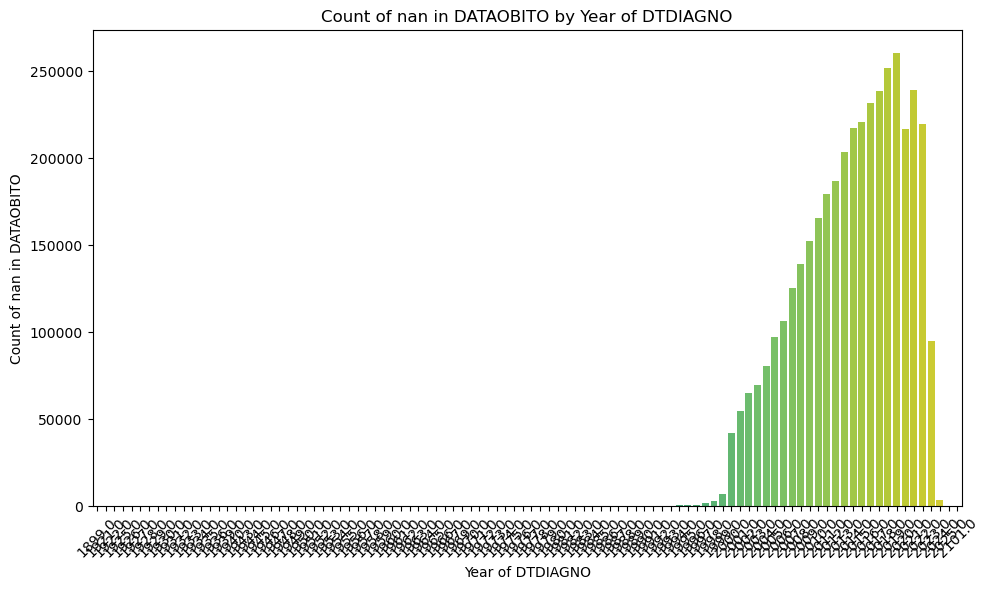

In [13]:
data['DTDIAGNO_Year'] = pd.to_datetime(data['DTDIAGNO'], errors='coerce').dt.year
obito_counts = data[data['DATAOBITO'].isna()].groupby('DTDIAGNO_Year').size()
plt.figure(figsize=(10, 6))
sns.barplot(x=obito_counts.index, y=obito_counts.values, palette='viridis')
plt.title("Count of nan in DATAOBITO by Year of DTDIAGNO")
plt.xlabel("Year of DTDIAGNO")
plt.ylabel("Count of nan in DATAOBITO")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

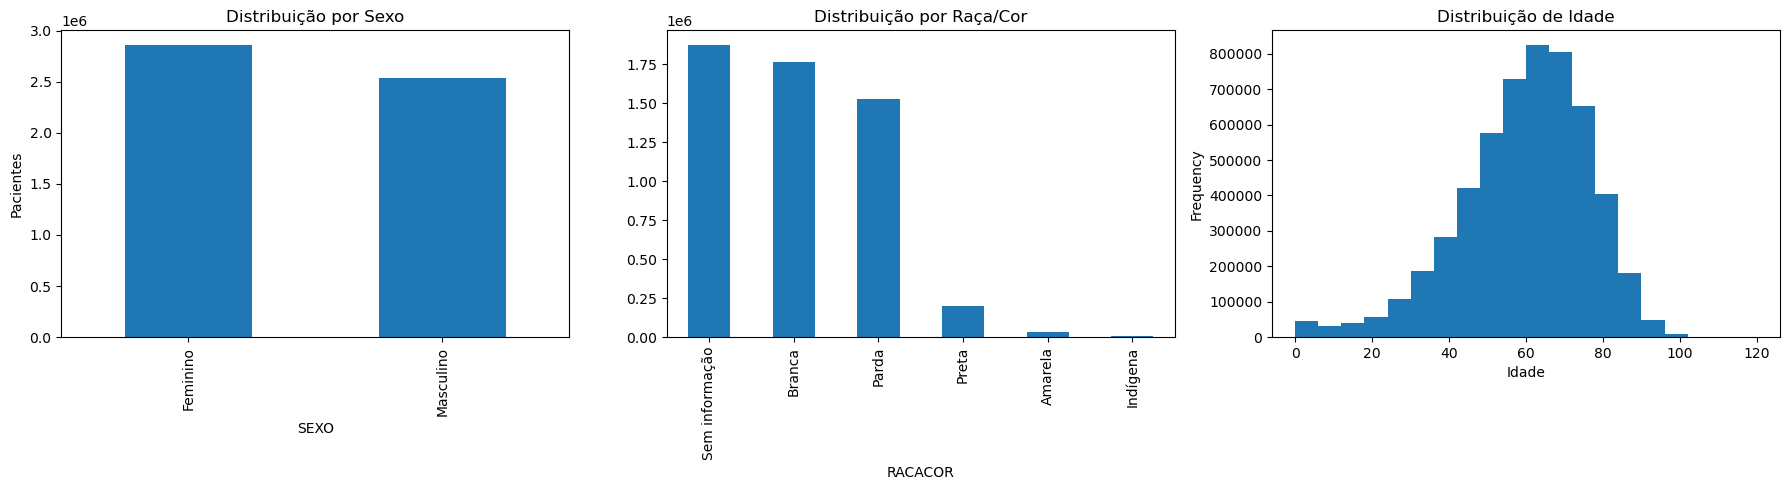

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

data['SEXO'].map(map_sexo).value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Distribuição por Sexo')
axes[0].set_ylabel('Pacientes')

data['RACACOR'].map(map_racacor).value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('Distribuição por Raça/Cor')

data['IDADE'].dropna().plot(kind='hist', bins=20, ax=axes[2])
axes[2].set_title('Distribuição de Idade')
axes[2].set_xlabel('Idade')

plt.tight_layout()
plt.show()

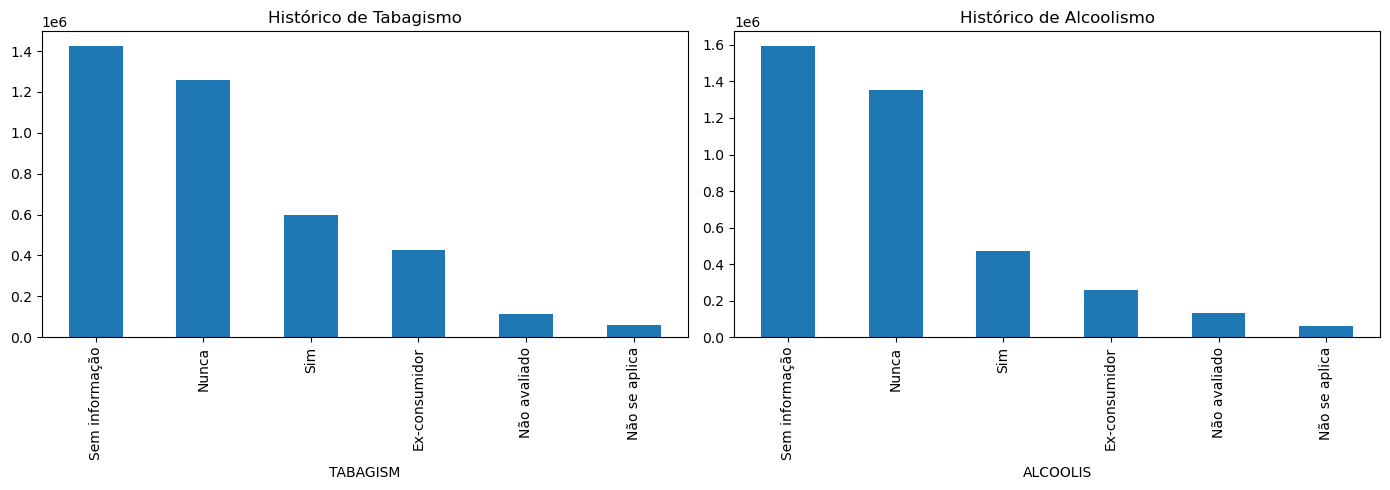

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data['TABAGISM'].map(map_tabagismo).value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Histórico de Tabagismo')

data['ALCOOLIS'].map(map_alcool).value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('Histórico de Alcoolismo')

plt.tight_layout()
plt.show()

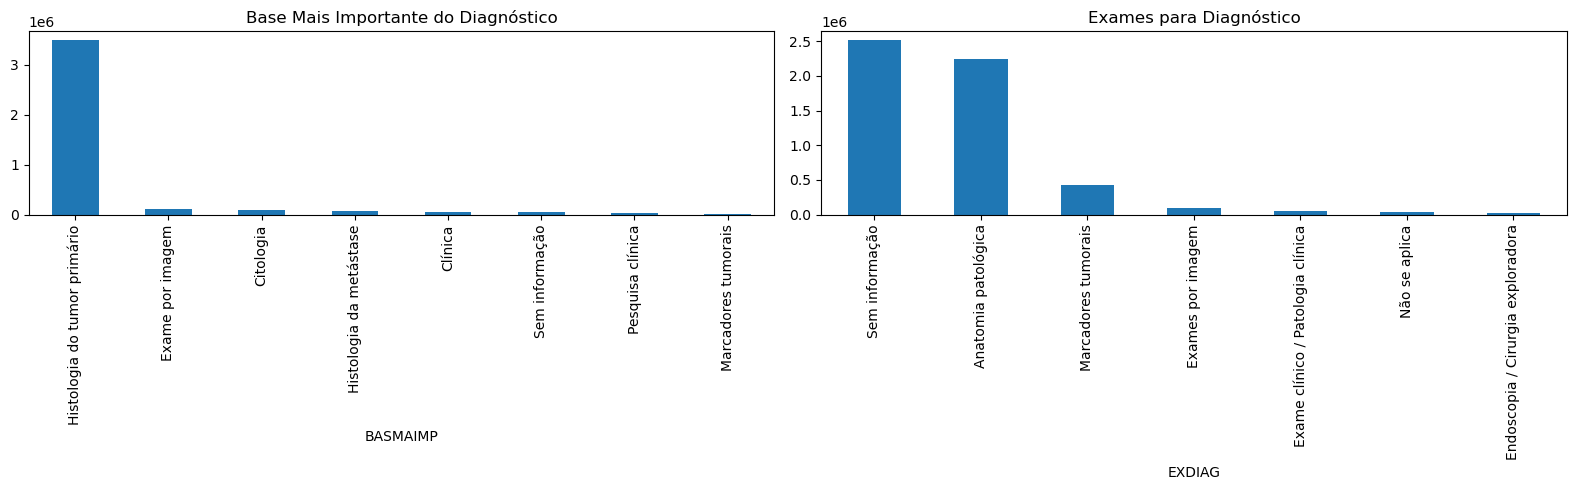

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

data['BASMAIMP'].map(map_basmaimp).value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Base Mais Importante do Diagnóstico')

data['EXDIAG'].astype(str).str.strip().map(map_exdiag).fillna('Sem informação') \
    .value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('Exames para Diagnóstico')

plt.tight_layout()
plt.show()

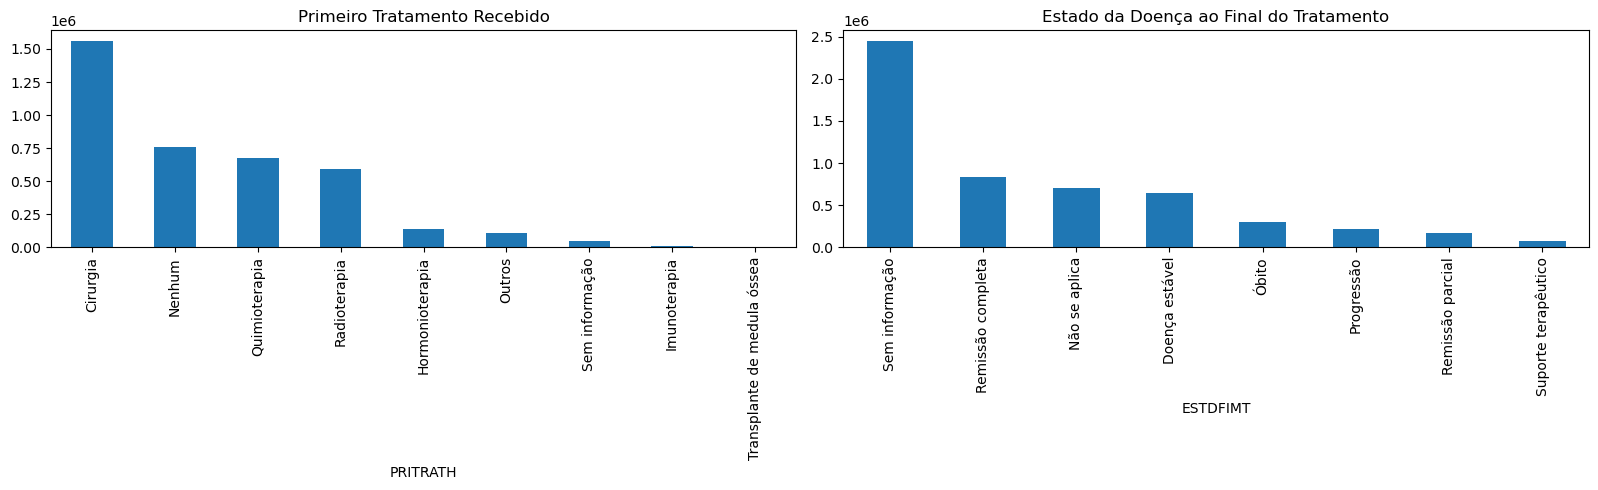

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

data['PRITRATH'].map(map_pritrath).value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Primeiro Tratamento Recebido')

data['ESTDFIMT'].map(map_estdfimt).value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('Estado da Doença ao Final do Tratamento')

plt.tight_layout()
plt.show()

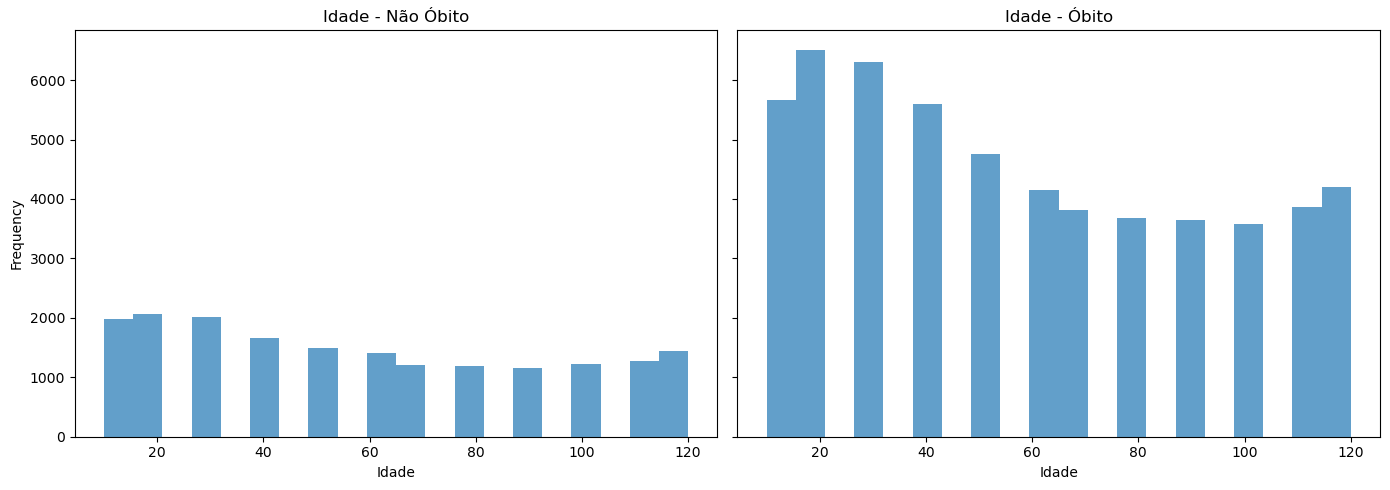

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

data.loc[data['STATUS_VITAL'] == 0, 'IDADE'].dropna().plot(
    kind='hist', bins=20, alpha=0.7, ax=axes[0]
)
axes[0].set_title('Idade - Não Óbito')
axes[0].set_xlabel('Idade')

data.loc[data['STATUS_VITAL'] == 1, 'IDADE'].dropna().plot(
    kind='hist', bins=20, alpha=0.7, ax=axes[1]
)
axes[1].set_title('Idade - Óbito')
axes[1].set_xlabel('Idade')

plt.tight_layout()
plt.show()

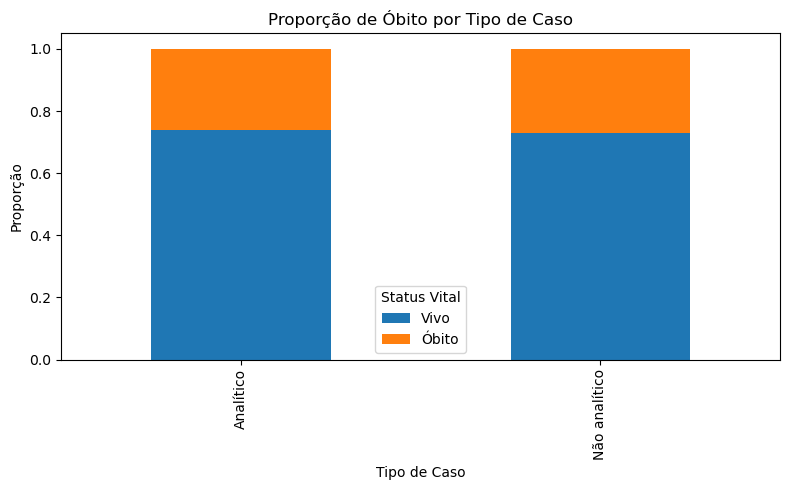

: 

In [ ]:
tpcaso = (
    data['TPCASO']
    .astype(str)
    .str.strip()
    .map(map_tp_caso)
    .fillna('Sem informação')
)

cross = pd.crosstab(tpcaso, data['STATUS_VITAL'].map(map_status_vital))
cross_prop = cross.div(cross.sum(axis=1), axis=0)

cross_prop.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5)
)

plt.title('Proporção de Óbito por Tipo de Caso')
plt.ylabel('Proporção')
plt.xlabel('Tipo de Caso')
plt.legend(title='Status Vital')
plt.tight_layout()
plt.show()

In [ ]:
#TODO: mais graficos e análises